In [1]:
import importlib_resources
import numpy as np
import sklearn.linear_model as lm
import matplotlib.pyplot as plt
from scipy.io import loadmat
from sklearn import model_selection
from dtuimldmtools import rlr_validate

In [2]:
import importlib_resources
import numpy as np
import xlrd
import pandas as pd
from scipy.linalg import svd 
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import sklearn.linear_model as lm

In [59]:
# Load csv file with data
df = pd.read_csv('null-corrected.csv')
df = df.drop(columns='index')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [60]:
df = pd.get_dummies(df, columns=['cp', 'thal', 'restecg', 'slope'], drop_first=True, dtype=float)
df

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,num,cp_2.0,cp_3.0,cp_4.0,thal_3.0,thal_6.0,thal_7.0,restecg_1.0,restecg_2.0,slope_2.0,slope_3.0
0,63.0,1.0,145.0,233.0,1.0,150.0,0.0,2.3,0.0,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
1,67.0,1.0,160.0,286.0,0.0,108.0,1.0,1.5,3.0,2,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
2,67.0,1.0,120.0,229.0,0.0,129.0,1.0,2.6,2.0,1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
3,37.0,1.0,130.0,250.0,0.0,187.0,0.0,3.5,0.0,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,41.0,0.0,130.0,204.0,0.0,172.0,0.0,1.4,0.0,0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45.0,1.0,110.0,264.0,0.0,132.0,0.0,1.2,0.0,1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
299,68.0,1.0,144.0,193.0,1.0,141.0,0.0,3.4,2.0,2,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
300,57.0,1.0,130.0,131.0,0.0,115.0,1.0,1.2,1.0,3,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
301,57.0,0.0,130.0,236.0,0.0,174.0,0.0,0.0,1.0,1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0


In [61]:

# 1. Adskil features og target
X = df.drop(columns='num')          # Features
y = df['num'].to_numpy()               # Target

# 2. Lav attributnavne med offset først
attributeNames = ["Offset"] + list(X.columns)


X = X.to_numpy()

# 4. Gem dimensions
N, M = X.shape

In [62]:
X

array([[ 63.,   1., 145., ...,   1.,   0.,   1.],
       [ 67.,   1., 160., ...,   1.,   1.,   0.],
       [ 67.,   1., 120., ...,   1.,   1.,   0.],
       ...,
       [ 57.,   1., 130., ...,   0.,   1.,   0.],
       [ 57.,   0., 130., ...,   1.,   1.,   0.],
       [ 38.,   1., 138., ...,   0.,   0.,   0.]], shape=(303, 19))

In [63]:
# Standardisering af data - træk middelværdi fra og divider med standardafvigelse
X_ = X - np.ones((N, 1)) * X.mean(axis=0)
X_scaled = X_ / X.std(axis=0)
N, M = X_scaled.shape
X_scaled

array([[ 0.94872647,  0.68620244,  0.75752504, ...,  1.02337544,
        -0.92676626,  3.66450153],
       [ 1.39200191,  0.68620244,  1.61121989, ...,  1.02337544,
         1.07902072, -0.27288841],
       [ 1.39200191,  0.68620244, -0.6652997 , ...,  1.02337544,
         1.07902072, -0.27288841],
       ...,
       [ 0.28381332,  0.68620244, -0.0961698 , ..., -0.97715849,
         1.07902072, -0.27288841],
       [ 0.28381332, -1.4572959 , -0.0961698 , ...,  1.02337544,
         1.07902072, -0.27288841],
       [-1.82174501,  0.68620244,  0.35913411, ..., -0.97715849,
        -0.92676626, -0.27288841]], shape=(303, 19))

In [64]:
X_scaled = np.concatenate((np.ones((X_scaled.shape[0], 1)), X_scaled), axis=1)
X_scaled

array([[ 1.        ,  0.94872647,  0.68620244, ...,  1.02337544,
        -0.92676626,  3.66450153],
       [ 1.        ,  1.39200191,  0.68620244, ...,  1.02337544,
         1.07902072, -0.27288841],
       [ 1.        ,  1.39200191,  0.68620244, ...,  1.02337544,
         1.07902072, -0.27288841],
       ...,
       [ 1.        ,  0.28381332,  0.68620244, ..., -0.97715849,
         1.07902072, -0.27288841],
       [ 1.        ,  0.28381332, -1.4572959 , ...,  1.02337544,
         1.07902072, -0.27288841],
       [ 1.        , -1.82174501,  0.68620244, ..., -0.97715849,
        -0.92676626, -0.27288841]], shape=(303, 20))

In [10]:
# filename = df

# X = df.drop(df.columns[13], axis=1).iloc[:, 1:].to_numpy()
# y = df['num'].to_numpy()

In [65]:
y

array([0, 2, 1, 0, 0, 0, 3, 0, 2, 1, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 3, 4, 0, 0, 0, 0, 3, 0, 2, 1, 0, 0, 0, 3, 1, 3, 0, 4, 0, 0, 0,
       1, 4, 0, 4, 0, 0, 0, 0, 2, 0, 1, 1, 1, 1, 0, 0, 2, 0, 1, 0, 2, 2,
       1, 0, 2, 1, 0, 3, 1, 1, 1, 0, 1, 0, 0, 3, 0, 0, 0, 3, 0, 0, 0, 0,
       0, 0, 0, 3, 0, 0, 0, 1, 2, 3, 0, 0, 0, 0, 0, 0, 3, 0, 2, 1, 2, 3,
       1, 1, 0, 2, 2, 0, 0, 0, 3, 2, 3, 4, 0, 3, 1, 0, 3, 3, 0, 0, 0, 0,
       0, 0, 0, 0, 4, 3, 1, 0, 0, 1, 0, 1, 0, 1, 4, 0, 0, 0, 0, 0, 0, 4,
       3, 1, 1, 1, 2, 0, 0, 4, 0, 0, 0, 0, 0, 0, 1, 0, 3, 0, 1, 0, 4, 1,
       0, 1, 0, 0, 3, 2, 0, 0, 1, 0, 0, 2, 1, 2, 0, 3, 1, 2, 0, 3, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 3, 3, 3, 0, 1, 0, 4, 0, 3, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 3, 1, 0, 0, 0, 3, 2, 0, 2, 1, 0, 0, 3, 2, 1, 0, 0, 0, 0,
       0, 2, 0, 2, 2, 1, 3, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 3, 0, 0,
       4, 2, 2, 2, 1, 0, 1, 0, 2, 0, 1, 0, 0, 0, 1, 0, 2, 0, 3, 0, 2, 4,
       2, 0, 0, 0, 1, 0, 2, 2, 1, 0, 3, 1, 1, 2, 3,

In [66]:
X_scaled

array([[ 1.        ,  0.94872647,  0.68620244, ...,  1.02337544,
        -0.92676626,  3.66450153],
       [ 1.        ,  1.39200191,  0.68620244, ...,  1.02337544,
         1.07902072, -0.27288841],
       [ 1.        ,  1.39200191,  0.68620244, ...,  1.02337544,
         1.07902072, -0.27288841],
       ...,
       [ 1.        ,  0.28381332,  0.68620244, ..., -0.97715849,
         1.07902072, -0.27288841],
       [ 1.        ,  0.28381332, -1.4572959 , ...,  1.02337544,
         1.07902072, -0.27288841],
       [ 1.        , -1.82174501,  0.68620244, ..., -0.97715849,
        -0.92676626, -0.27288841]], shape=(303, 20))

Fold 1/10: Optimal lambda = 1.00e+01, Generalization error = 0.0000
Fold 2/10: Optimal lambda = 1.00e+02, Generalization error = 0.0000
Fold 3/10: Optimal lambda = 1.00e+02, Generalization error = 0.0000
Fold 4/10: Optimal lambda = 1.00e+02, Generalization error = 0.0000
Fold 5/10: Optimal lambda = 1.00e+01, Generalization error = 0.0000
Fold 6/10: Optimal lambda = 1.00e+02, Generalization error = 0.0000
Fold 7/10: Optimal lambda = 1.00e+02, Generalization error = 0.0000
Fold 8/10: Optimal lambda = 1.00e+01, Generalization error = 0.0000
Fold 9/10: Optimal lambda = 1.00e+01, Generalization error = 0.0000
Fold 10/10: Optimal lambda = 1.00e+02, Generalization error = 0.0000


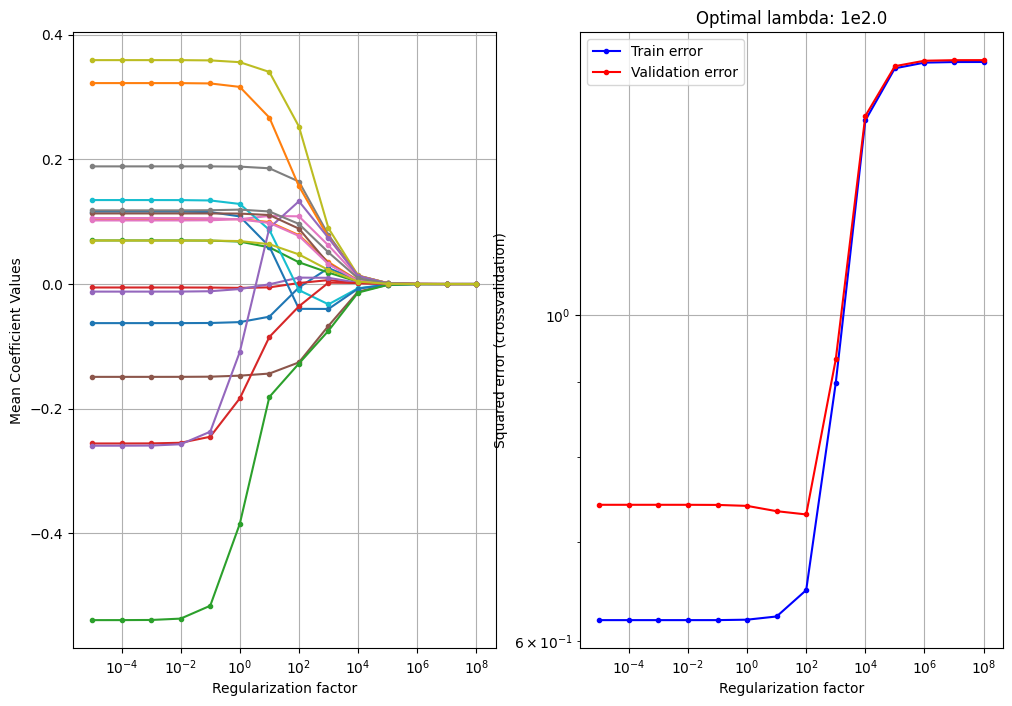

Linear regression without feature selection:
- Training error: 0.6166296448905737
- Test error:     0.7202295462533201
- R^2 train:     0.5899487972011535
- R^2 test:     0.5072428150381152

Regularized linear regression:
- Training error: 0.6329514877211373
- Test error:     0.716727887773955
- R^2 train:     0.5790949705322231
- R^2 test:     0.5096385337141482

Weights in last fold:
         Offset            0.94
            age           -0.01
            sex            0.08
       trestbps            0.04
           chol             0.0
            fbs            0.01
        thalach           -0.13
          exang            0.11
        oldpeak            0.17
             ca            0.26
         cp_2.0           -0.01
         cp_3.0           -0.04
         cp_4.0            0.16
       thal_3.0           -0.13
       thal_6.0           -0.04
       thal_7.0            0.13
    restecg_1.0            0.09
    restecg_2.0            0.08
      slope_2.0             0.1
   

In [67]:
# attributeNames = list(df.drop(columns='num').columns)
# N, M = X.shape

# # Add offset attribute
# X = np.concatenate((np.ones((X.shape[0], 1)), X), 1)
# attributeNames = ["Offset"] + attributeNames
M = M + 1

## Crossvalidation
# Create crossvalidation partition for evaluation
K = 10
CV = model_selection.KFold(K, shuffle=True, random_state=42)
# CV = model_selection.KFold(K, shuffle=False)

# Values of lambda
lambdas = np.power(10.0, range(-5, 9))

# Initialize variables
# T = len(lambdas)
Error_train = np.empty((K, 1))
Error_test = np.empty((K, 1))
Error_train_rlr = np.empty((K, 1))
Error_test_rlr = np.empty((K, 1))
Error_train_nofeatures = np.empty((K, 1))
Error_test_nofeatures = np.empty((K, 1))
w_rlr = np.empty((M, K))
mu = np.empty((K, M - 1))
sigma = np.empty((K, M - 1))
w_noreg = np.empty((M, K))

ann_gen_error = []
lr_gen_error = []

k = 0
for train_index, test_index in CV.split(X_scaled, y):
    # extract training and test set for current CV fold
    X_train = X_scaled[train_index]
    y_train = y[train_index]
    X_test = X_scaled[test_index]
    y_test = y[test_index]
    internal_cross_validation = 10

    (
        opt_val_err,
        opt_lambda,
        mean_w_vs_lambda,
        train_err_vs_lambda,
        test_err_vs_lambda,
    ) = rlr_validate(X_train, y_train, lambdas, internal_cross_validation)
    print(f"Fold {k+1}/{K}: Optimal lambda = {opt_lambda:.2e}, Generalization error = {Error_test_rlr[k, 0]:.4f}")
    # lr_gen_error.append(Error_test_rlr[k, 0])

    

    # Standardize outer fold based on training set, and save the mean and standard
    # deviations since they're part of the model (they would be needed for
    # making new predictions) - for brevity we won't always store these in the scripts
    mu[k, :] = np.mean(X_train[:, 1:], 0)
    sigma[k, :] = np.std(X_train[:, 1:], 0)

    X_train[:, 1:] = (X_train[:, 1:] - mu[k, :]) / sigma[k, :]
    X_test[:, 1:] = (X_test[:, 1:] - mu[k, :]) / sigma[k, :]

    Xty = X_train.T @ y_train
    XtX = X_train.T @ X_train

    # Compute mean squared error without using the input data at all
    Error_train_nofeatures[k] = (
        np.square(y_train - y_train.mean()).sum(axis=0) / y_train.shape[0]
    )
    Error_test_nofeatures[k] = (
        np.square(y_test - y_test.mean()).sum(axis=0) / y_test.shape[0]
    )

    # Estimate weights for the optimal value of lambda, on entire training set
    lambdaI = opt_lambda * np.eye(M)
    lambdaI[0, 0] = 0  # Do no regularize the bias term
    w_rlr[:, k] = np.linalg.solve(XtX + lambdaI, Xty).squeeze()
    # Compute mean squared error with regularization with optimal lambda
    Error_train_rlr[k] = (
        np.square(y_train - X_train @ w_rlr[:, k]).sum(axis=0) / y_train.shape[0]
    )
    Error_test_rlr[k] = (
        np.square(y_test - X_test @ w_rlr[:, k]).sum(axis=0) / y_test.shape[0]
    )
    lr_gen_error.append(Error_test_rlr[k, 0])

    # Estimate weights for unregularized linear regression, on entire training set
    w_noreg[:, k] = np.linalg.solve(XtX, Xty).squeeze()
    # Compute mean squared error without regularization
    Error_train[k] = (
        np.square(y_train - X_train @ w_noreg[:, k]).sum(axis=0) / y_train.shape[0]
    )
    Error_test[k] = (
        np.square(y_test - X_test @ w_noreg[:, k]).sum(axis=0) / y_test.shape[0]
    )
    
    # OR ALTERNATIVELY: you can use sklearn.linear_model module for linear regression:
    # m = lm.LinearRegression().fit(X_train, y_train)
    # Error_train[k] = np.square(y_train-m.predict(X_train)).sum()/y_train.shape[0]
    # Error_test[k] = np.square(y_test-m.predict(X_test)).sum()/y_test.shape[0]

    # Display the results for the last cross-validation fold
    if k == K - 1:
        plt.figure(k, figsize=(12, 8))
        plt.subplot(1, 2, 1)
        plt.semilogx(lambdas, mean_w_vs_lambda.T[:, 1:], ".-")  # Don't plot the bias term
        plt.xlabel("Regularization factor")
        plt.ylabel("Mean Coefficient Values")
        plt.grid()
        # You can choose to display the legend, but it's omitted for a cleaner
        # plot, since there are many attributes
        # legend(attributeNames[1:], loc='best')

        plt.subplot(1, 2, 2)
        plt.title("Optimal lambda: 1e{0}".format(np.log10(opt_lambda)))
        plt.loglog(
            lambdas, train_err_vs_lambda.T, "b.-", lambdas, test_err_vs_lambda.T, "r.-"
        )
        plt.xlabel("Regularization factor")
        plt.ylabel("Squared error (crossvalidation)")
        plt.legend(["Train error", "Validation error"])
        plt.grid()

    # To inspect the used indices, use these print statements
    # print('Cross validation fold {0}/{1}:'.format(k+1,K))
    # print('Train indices: {0}'.format(train_index))
    # print('Test indices: {0}\n'.format(test_index))

    k += 1

plt.show()
# Display results
print("Linear regression without feature selection:")
print("- Training error: {0}".format(Error_train.mean()))
print("- Test error:     {0}".format(Error_test.mean()))
print(
    "- R^2 train:     {0}".format(
        (Error_train_nofeatures.sum() - Error_train.sum())
        / Error_train_nofeatures.sum()
    )
)
print(
    "- R^2 test:     {0}\n".format(
        (Error_test_nofeatures.sum() - Error_test.sum()) / Error_test_nofeatures.sum()
    )
)
print("Regularized linear regression:")
print("- Training error: {0}".format(Error_train_rlr.mean()))
print("- Test error:     {0}".format(Error_test_rlr.mean()))
print(
    "- R^2 train:     {0}".format(
        (Error_train_nofeatures.sum() - Error_train_rlr.sum())
        / Error_train_nofeatures.sum()
    )
)
print(
    "- R^2 test:     {0}\n".format(
        (Error_test_nofeatures.sum() - Error_test_rlr.sum())
        / Error_test_nofeatures.sum()
    )
)

print("Weights in last fold:")
for m in range(M):
    print("{:>15} {:>15}".format(attributeNames[m], np.round(w_rlr[m, -1], 2)))

print("Ran Exercise 8.1.1")


In [68]:
lr_gen_error

[np.float64(0.7947337227765456),
 np.float64(0.5519055151745557),
 np.float64(0.6944719994972745),
 np.float64(0.4303656366175066),
 np.float64(0.9151065687275229),
 np.float64(0.7968895427607082),
 np.float64(0.6386183502832037),
 np.float64(0.9314661312990705),
 np.float64(0.7182210246606794),
 np.float64(0.6955003859424832)]

In [69]:
lr_gen_error = np.abs(lr_gen_error)
lr_gen_error

array([0.79473372, 0.55190552, 0.694472  , 0.43036564, 0.91510657,
       0.79688954, 0.63861835, 0.93146613, 0.71822102, 0.69550039])

In [70]:
attributeNames

['Offset',
 'age',
 'sex',
 'trestbps',
 'chol',
 'fbs',
 'thalach',
 'exang',
 'oldpeak',
 'ca',
 'cp_2.0',
 'cp_3.0',
 'cp_4.0',
 'thal_3.0',
 'thal_6.0',
 'thal_7.0',
 'restecg_1.0',
 'restecg_2.0',
 'slope_2.0',
 'slope_3.0']

In [71]:
w_rlr[:, -1]

array([ 0.93772894, -0.00889372,  0.08060505,  0.0358572 ,  0.00171673,
        0.01010651, -0.12717518,  0.10976851,  0.16701531,  0.2601483 ,
       -0.00595115, -0.03675156,  0.1611484 , -0.12870445, -0.03868214,
        0.13342514,  0.09212126,  0.07907564,  0.09779215,  0.04883412])

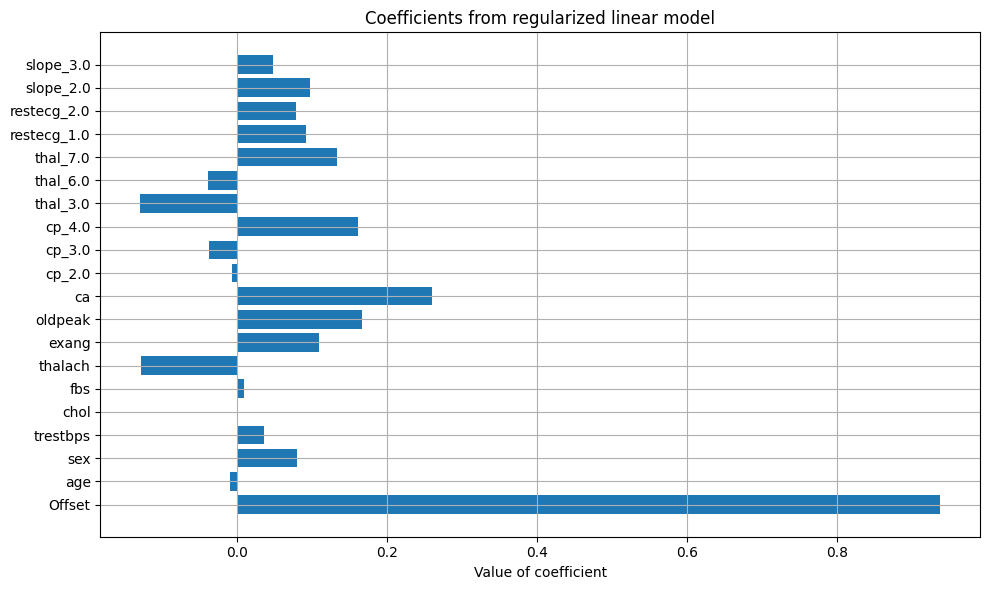

In [74]:
# Visualiering
coefficients = w_rlr[:, -1]  # -1 = sidste fold
feature_names = attributeNames[:]


plt.figure(figsize=(10, 6))
plt.barh(range(len(coefficients)), coefficients)
plt.yticks(range(len(coefficients)), feature_names)
plt.xlabel("Value of coefficient")
plt.title("Coefficients from regularized linear model")
plt.grid(True)
plt.tight_layout()
plt.show()


In [75]:
generalization_errors = []
y_train_means = []

for fold_idx, (train_index, test_index) in enumerate(CV.split(X, y)):
    y_train = y[train_index]
    y_test = y[test_index]

    # Brug gennemsnittet af y_train som konstant forudsigelse
    y_train_mean = np.mean(y_train)
    y_pred = np.full_like(y_test, fill_value=y_train_mean)                   

    # Beregn generalization error (MSE) på testdata
    gen_error = np.mean((y_test - y_pred) ** 2)

    # Gem og print
    y_train_means.append(y_train_mean)
    generalization_errors.append(gen_error)

    print(f"Fold {fold_idx + 1}: y_train mean = {y_train_mean:.4f}, Generalization error = {gen_error:.4f}")


Fold 1: y_train mean = 0.8971, Generalization error = 3.5484
Fold 2: y_train mean = 0.9449, Generalization error = 2.0968
Fold 3: y_train mean = 0.9632, Generalization error = 1.4839
Fold 4: y_train mean = 0.9451, Generalization error = 2.0000
Fold 5: y_train mean = 0.9231, Generalization error = 2.8000
Fold 6: y_train mean = 0.9451, Generalization error = 2.4000
Fold 7: y_train mean = 0.9744, Generalization error = 1.1333
Fold 8: y_train mean = 0.9011, Generalization error = 3.4000
Fold 9: y_train mean = 0.9414, Generalization error = 2.4333
Fold 10: y_train mean = 0.9377, Generalization error = 2.5333


Comparison of the regression models:

In [83]:
from dtuimldmtools.statistics.statistics import correlated_ttest
import numpy as np

In [88]:
baseline = [3.5484,2.0968,1.4839,2.0,2.8,2.4,1.13,3.4,2.433,2.53]
ann_gen_error = ([0.719367265701294, 0.5709824562072754, 0.5101677775382996, 0.28891289234161377, 0.5539467334747314, 0.5465726256370544, 0.560657799243927, 0.5351351499557495, 0.5453031659126282, 0.7259019017219543])

In [81]:
lr_gen_error

array([0.79473372, 0.55190552, 0.694472  , 0.43036564, 0.91510657,
       0.79688954, 0.63861835, 0.93146613, 0.71822102, 0.69550039])

In [84]:

r = []
m = 10

# Difference between ANN and LR

for dm in range(m):
    forskel = (ann_gen_error[dm] - lr_gen_error[dm])
    r.append(float(forskel))

alpha = 0.05
rho = 1/10
p_setupII, CI_setupII = correlated_ttest(r, rho, alpha=alpha)

p_setupII, CI_setupII


(np.float64(0.03080758157381472),
 (np.float64(-0.30346370093067626), np.float64(-0.01860252107032828)))

In [85]:
# Difference between ANN and baseline

r_1 = []

for dm in range(m):
    forskel = (ann_gen_error[dm] - baseline[dm])
    r_1.append(float(forskel))

alpha = 0.05
rho = 1/10
p_setupII, CI_setupII = correlated_ttest(r_1, rho, alpha=alpha)

p_setupII, CI_setupII


(np.float64(0.00025508872266236945),
 (np.float64(-2.5372371882905544), np.float64(-1.1157932581625398)))

In [89]:
# Difference between LR and baseline

r_2 = []

for dm in range(m):
    forskel = (lr_gen_error[dm] - baseline[dm])
    r_2.append(float(forskel))

alpha = 0.05
rho = 1/10
p_setupII, CI_setupII = correlated_ttest(r_2, rho, alpha=alpha)

p_setupII, CI_setupII

(np.float64(0.0003043237180745678),
 (np.float64(-2.329535391930029), np.float64(-1.0014288325220606)))